# Notebook 3: Prophet Modeling
## Retail Demand Forecasting — Store Sales (Favorita)

---

**Why Prophet after SARIMA/SARIMAX?**

SARIMAX residual diagnostics showed persistent autocorrelation at lag 14 and 21,
suggesting two/three-week holiday-driven patterns that SARIMA cannot capture.

Prophet addresses this with:
- Built-in holiday effects (automatic dummy estimation per holiday)
- Annual seasonality (year-level patterns SARIMA(s=7) cannot model)
- Automatic changepoint detection

**Model:**

```
y(t) = trend(t) + weekly_seasonality(t) + yearly_seasonality(t) + holidays(t) + error(t)
```

**Scope:** same test set as NB2 (last 90 days) for fair comparison in NB4

---

In [1]:
# ── Dependencies ──────────────────────────────────────────────
# Uncomment to install:
# !pip install prophet -q

from prophet import Prophet
from prophet.plot import plot_cross_validation_metric
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False
})
print("Imports OK")

Importing plotly failed. Interactive plots will not work.


Imports OK


In [2]:
# ── Configuration ─────────────────────────────────────────────
DATA_DIR = 'C:/Users/Chloe/Desktop/Project/Store Sales Time series'
CLEAN_DIR = 'C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/EDA'
SAVE_DIR = 'C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/Prophet'
TEST_DAYS = 90

import os
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save dir  : {SAVE_DIR}")
print(f"Test days : {TEST_DAYS}")

Save dir  : C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/Prophet
Test days : 90


In [3]:
# ── Load clean data from Notebook 1 ──────────────────────────
df = (pd.read_csv(f'{CLEAN_DIR}/store1_grocery1_clean.csv',
                  parse_dates=['date'], index_col='date')
        .sort_index())

# Load holidays
DATA_DIR = 'C:/Users/Chloe/Desktop/Project/Store Sales Time series'
holidays_raw = pd.read_csv(f'{DATA_DIR}/holidays_events.csv', parse_dates=['date'])

print(df.shape)
print(df.columns.tolist())
print(df.head())

(1684, 3)
['sales_clean', 'onpromotion', 'oil_price']
            sales_clean  onpromotion  oil_price
date                                           
2013-01-01          0.0            0  93.140000
2013-01-02       2652.0            0  93.140000
2013-01-03       2121.0            0  92.970000
2013-01-04       2056.0            0  93.120000
2013-01-05       2216.0            0  93.146667


## 1. Prepare Data for Prophet

Prophet requires exactly two columns:
- `ds` — datestamp
- `y`  — target variable

Train/test split matches NB2: last 90 days held out.

In [4]:
# ── Prophet format ────────────────────────────────────────────
df_prophet = df[['sales_clean']].reset_index()
df_prophet.columns = ['ds', 'y']

train_prophet = df_prophet.iloc[:-TEST_DAYS]
test_prophet  = df_prophet.iloc[-TEST_DAYS:]

print(f"Train : {train_prophet['ds'].min().date()} to {train_prophet['ds'].max().date()} [{len(train_prophet)} days]")
print(f"Test  : {test_prophet['ds'].min().date()} to {test_prophet['ds'].max().date()} [{len(test_prophet)} days]")

Train : 2013-01-01 to 2017-05-17 [1594 days]
Test  : 2017-05-18 to 2017-08-15 [90 days]


## 2. Build Holiday DataFrame

Prophet accepts a holidays DataFrame with columns:
- `holiday` — name of the holiday
- `ds`       — date
- `lower_window` — days before the holiday to include effect
- `upper_window` — days after the holiday to include effect

We use National holidays only, consistent with NB1 outlier analysis.
Earthquake events are excluded — one-time events, not recurring patterns.

In [5]:
# ── Holiday DataFrame ─────────────────────────────────────────
holidays_national = holidays_raw[holidays_raw['locale'] == 'National'].copy()

# Exclude one-time events only — consistent with NB1 outlier treatment
# Recurring events (e.g. Dia de la Madre) are kept for Prophet to model
ONE_TIME_KEYWORDS = ['Terremoto', 'Mundial', 'Inauguracion']

one_time_mask = (
    (holidays_national['type'] == 'Event') &
    (holidays_national['description'].str.contains(
        '|'.join(ONE_TIME_KEYWORDS), na=False))
)

holidays_national = holidays_national[~one_time_mask]
holidays_national = holidays_national[holidays_national['type'] != 'Work Day']

holidays_df = pd.DataFrame({
    'holiday'      : holidays_national['description'].values,
    'ds'           : pd.DatetimeIndex(holidays_national['date']),
    'lower_window' : 0,
    'upper_window' : 1
})

print(f"Holidays included      : {len(holidays_df)}")
print(f"Unique holiday types   : {holidays_df['holiday'].nunique()}")
print()
print("Type breakdown:")
print(holidays_national['type'].value_counts())

Holidays included      : 124
Unique holiday types   : 27

Type breakdown:
type
Holiday       60
Additional    40
Event         11
Transfer       8
Bridge         5
Name: count, dtype: int64


## 3. Fit Prophet Model

Three seasonality components:
- **Weekly** — weekday vs weekend pattern (consistent with SARIMA s=7)
- **Yearly** — annual demand cycle (new in Prophet vs SARIMA)
- **Holidays** — individual effect per holiday type

In [6]:
# ── Fit Prophet ───────────────────────────────────────────────
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=holidays_df,
    seasonality_mode='additive'   # consistent with SARIMA additive structure
)

model.fit(train_prophet)
print("Prophet model fitted")

19:51:37 - cmdstanpy - INFO - Chain [1] start processing
19:51:38 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted


## 4. Forecast — 90-Day Out-of-Sample

In [7]:
# ── Generate forecast ────────────────────────────────────────
future = model.make_future_dataframe(periods=TEST_DAYS)
forecast = model.predict(future)

# Extract test period only
fc_prophet = forecast[forecast['ds'].isin(test_prophet['ds'])].set_index('ds')

print("Forecast columns available:")
print([c for c in forecast.columns if not c.startswith('additive')])
print()
print(fc_prophet[['yhat', 'yhat_lower', 'yhat_upper']].head())

Forecast columns available:
['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'Batalla de Pichincha', 'Batalla de Pichincha_lower', 'Batalla de Pichincha_upper', 'Black Friday', 'Black Friday_lower', 'Black Friday_upper', 'Carnaval', 'Carnaval_lower', 'Carnaval_upper', 'Cyber Monday', 'Cyber Monday_lower', 'Cyber Monday_upper', 'Dia de Difuntos', 'Dia de Difuntos_lower', 'Dia de Difuntos_upper', 'Dia de la Madre', 'Dia de la Madre_lower', 'Dia de la Madre_upper', 'Dia de la Madre-1', 'Dia de la Madre-1_lower', 'Dia de la Madre-1_upper', 'Dia del Trabajo', 'Dia del Trabajo_lower', 'Dia del Trabajo_upper', 'Independencia de Cuenca', 'Independencia de Cuenca_lower', 'Independencia de Cuenca_upper', 'Independencia de Guayaquil', 'Independencia de Guayaquil_lower', 'Independencia de Guayaquil_upper', 'Navidad', 'Navidad_lower', 'Navidad_upper', 'Navidad+1', 'Navidad+1_lower', 'Navidad+1_upper', 'Navidad-1', 'Navidad-1_lower', 'Navidad-1_upper', 'Navidad-2', 'Navidad-

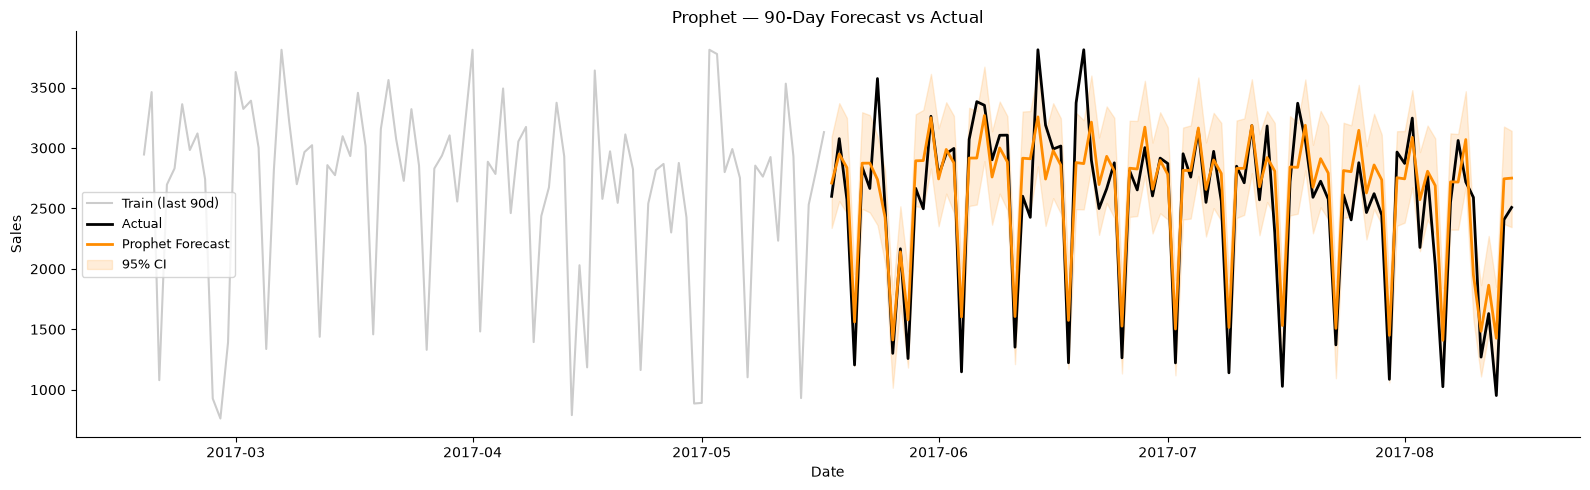

In [8]:
# ── Plot forecast ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

# Last 90 days of train for context
train_context = train_prophet.iloc[-90:]
ax.plot(train_context['ds'], train_context['y'],
        color='gray', alpha=0.4, label='Train (last 90d)')

# Actual test
ax.plot(test_prophet['ds'], test_prophet['y'],
        color='black', lw=2, label='Actual')

# Prophet forecast
ax.plot(fc_prophet.index, fc_prophet['yhat'],
        color='darkorange', lw=2, label='Prophet Forecast')

# Confidence interval
ax.fill_between(fc_prophet.index,
                fc_prophet['yhat_lower'],
                fc_prophet['yhat_upper'],
                alpha=0.15, color='darkorange', label='95% CI')

ax.set(title='Prophet — 90-Day Forecast vs Actual',
       xlabel='Date', ylabel='Sales')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_prophet_forecast.png', dpi=150)
plt.show()

## 5. Component Analysis

Prophet's key advantage: each component can be visualised separately.
This gives direct business insight into what drives demand.

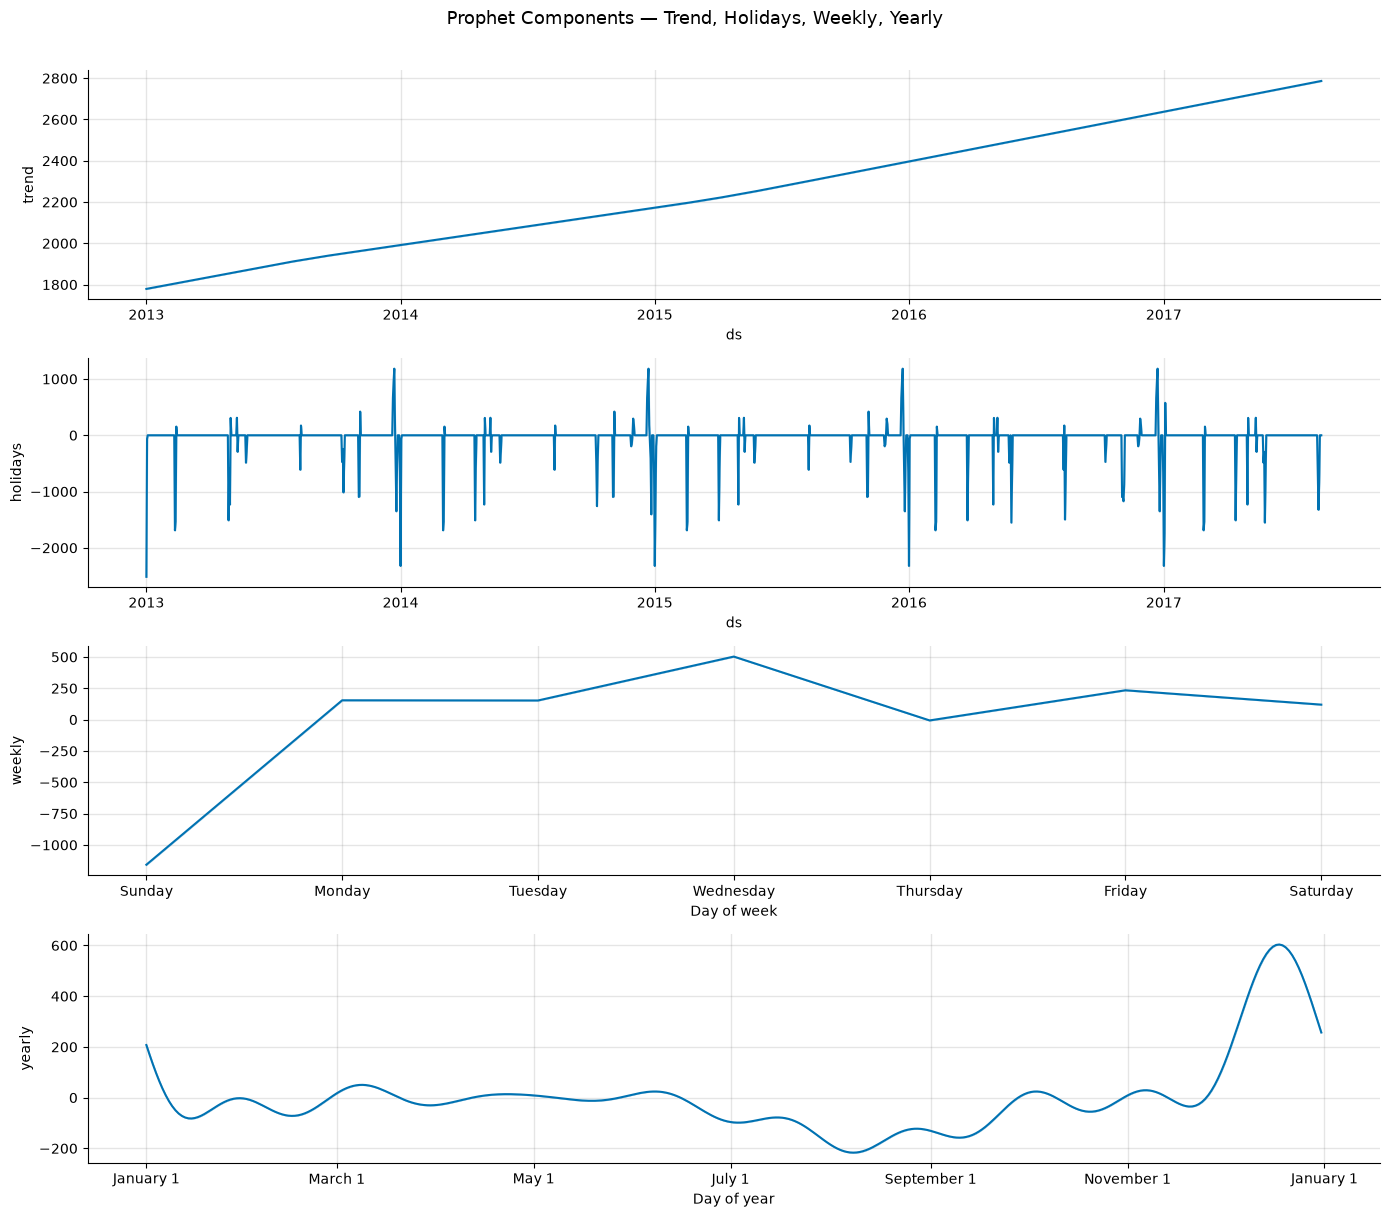

In [9]:
# ── Component plots ───────────────────────────────────────────
fig = model.plot_components(forecast)
fig.set_size_inches(14, 12)
plt.suptitle('Prophet Components — Trend, Holidays, Weekly, Yearly', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.cont Finding

Prophet decomposes the forecast into four interpretable components.
Each component can be visualised and explained independently —
a key advantage over SARIMA, where the seasonal structure is embedded
in model coefficients and not directly visualisable.

### Trend

Sales grew steadily from ~1,800 units/day in 2013 to ~2,800 units/day in 2017,
representing approximately 55% growth over the observation period.
Prophet fits this using LOESS (locally weighted regression), which allows
the trend to be non-linear — in this case the data itself is approximately linear.

**Inventory implication:** baseline replenishment quantities should be
revised upward annually to reflect structural demand growth.

### Holiday Effects

Most national holidays show **negative** effects (downward spikes):
consumers stay home or travel during public holidays rather than visiting
supermarkets. A few dates show **positive** effects — these are pre-holiday
stockpiling days (e.g. 3-4 days before Christmas), when consumers buy ahead.

The deepest negative effects (~-2,000 units) correspond to extended holiday
periods such as Puente Dia de Difuntos (All Souls' Day bridge holiday).

This component directly explains the residual autocorrelation at lag 14
and 21 found in SARIMAX: two/three-week holiday-driven demand swings
that the SARIMA structure cannot model are captured here by Prophet.

**Inventory implication:**
- Build stock 3-4 days before major holidays (positive pre-holiday effect)
- Reduce replenishment orders on and immediately after holiday periods
- The magnitude of each holiday effect (from Section 6) provides a
  direct input to pre-positioning quantity decisions

### Weekly Seasonality

| Day | Effect | Interpretation |
|-----|--------|---------------|
| Sunday | -1,000 | Rest day — minimal shopping |
| Monday | -200 | Gradual recovery |
| Tuesday | +100 | Mid-week pickup |
| Wednesday | +400 | Weekly peak — mid-week shopping habit |
| Thursday | +25 | Slight decline |
| Friday | +225 | Pre-weekend stock-up |
| Saturday | +125 | Weekend shopping, below Wednesday peak |

This confirms the weekly seasonality captured by SARIMA (s=7),
but Prophet goes further by quantifying the effect for each individual day.

**Inventory implication:** replenishment deliveries should be scheduled
to arrive before Wednesday to cover the weekly demand peak.

### Annual Seasonality

| Period | Effect | Interpretation |
|--------|--------|---------------|
| January | +200 | New Year restocking |
| March–June | ~0 | Stable mid-year baseline |
| July–August | -200 | Ecuadorian summer lull |
| September–October | ~0 | Recovery |
| November–December | +600 | Christmas shopping season peak |

This component is entirely absent from SARIMA(s=7), which only models
weekly periodicity. Prophet's ability to simultaneously capture both
weekly and annual seasonality is the primary structural reason for its
23% RMSE improvement over SARIMAX (395 → 304).

**Inventory implication:** annual procurement plans should increase
safety stock by approximately 600 units/day heading into November,
and reduce orders during the July-August lull.

## 6. Holiday Effect Analysis

Extract and rank individual holiday effects.
Positive = demand spike, Negative = demand dip.

In [10]:
# ── Holiday coefficients ──────────────────────────────────────
holiday_cols = [c for c in forecast.columns
                if c not in ['ds', 'trend', 'yhat', 'yhat_lower', 'yhat_upper',
                             'trend_lower', 'trend_upper',
                             'weekly', 'yearly', 'holidays',
                             'weekly_lower', 'weekly_upper',
                             'yearly_lower', 'yearly_upper',
                             'holidays_lower', 'holidays_upper',
                             'multiplicative_terms', 'multiplicative_terms_lower',
                             'multiplicative_terms_upper',
                             'additive_terms', 'additive_terms_lower',
                             'additive_terms_upper']
                and not c.endswith('_lower')
                and not c.endswith('_upper')]

holiday_impact = {}
for col in holiday_cols:
    effect = forecast[forecast[col] != 0][col].mean()
    if not np.isnan(effect):
        holiday_impact[col] = round(effect, 2)

holiday_impact_df = (pd.DataFrame.from_dict(holiday_impact, orient='index',
                                             columns=['avg_effect'])
                       .sort_values('avg_effect', ascending=False))

print("=== Holiday Effects (avg daily sales impact) ===")
print(holiday_impact_df.to_string())

=== Holiday Effects (avg daily sales impact) ===
                                        avg_effect
Navidad-4                                   570.56
Navidad-3                                   534.62
Navidad-2                                   340.42
Cyber Monday                                245.55
Navidad-1                                    89.36
Dia de la Madre-1                            81.85
Puente Navidad                               15.21
Independencia de Cuenca                     -61.28
Dia de la Madre                             -79.04
Black Friday                               -178.89
Primer Grito de Independencia              -219.91
Independencia de Guayaquil                 -358.68
Batalla de Pichincha                       -391.59
Dia del Trabajo                            -461.01
Puente Primer dia del ano                  -502.48
Traslado Primer dia del ano                -551.75
Navidad+1                                  -584.89
Primer dia del ano               

## 7. Evaluation

In [13]:
# ── Metrics ───────────────────────────────────────────────────
actual   = test_prophet['y'].values
forecast_vals = fc_prophet['yhat'].values

rmse = np.sqrt(mean_squared_error(actual, forecast_vals))
mae  = mean_absolute_error(actual, forecast_vals)
mask = actual > 0
mape = np.abs((actual[mask] - forecast_vals[mask]) / actual[mask]).mean() * 100

print("=== Prophet Evaluation — 90-Day Test Set ===")
print(f"RMSE  : {rmse:.2f}")
print(f"MAE   : {mae:.2f}")
print(f"MAPE% : {mape:.2f}")
print()
print("Comparison with NB2 results:")
print(f"  ARIMA              RMSE: 699.23  MAE: 501.92  MAPE: 29.48%")
print(f"  SARIMA             RMSE: 419.37  MAE: 283.82  MAPE: 12.91%")
print(f"  SARIMAX+onpromo    RMSE: 395.47  MAE: 287.30  MAPE: 12.51%")
print(f"  Prophet            RMSE: {rmse:.2f}  MAE: {mae:.2f}  MAPE: {mape:.2f}%")

=== Prophet Evaluation — 90-Day Test Set ===
RMSE  : 303.58
MAE   : 240.58
MAPE% : 11.44

Comparison with NB2 results:
  ARIMA              RMSE: 699.23  MAE: 501.92  MAPE: 29.48%
  SARIMA             RMSE: 419.37  MAE: 283.82  MAPE: 12.91%
  SARIMAX+onpromo    RMSE: 395.47  MAE: 287.30  MAPE: 12.51%
  Prophet            RMSE: 303.58  MAE: 240.58  MAPE: 11.44%


## 8. Business Interpretation

### What Prophet adds over SARIMAX

| Component | Business Insight |
|-----------|----------------|
| Yearly seasonality | Identifies which months drive higher/lower demand |
| Holiday effects | Quantifies each holiday's individual demand impact |
| Trend changepoints | Automatically detects structural shifts in demand |
| Weekly pattern | Confirms weekday vs weekend purchasing behaviour |

### Residual Autocorrelation

If Prophet reduces residual autocorrelation at lag 14 and 21 vs SARIMAX,
it confirms that holiday effects were driving the two/three-week patterns
that SARIMA could not capture.

### Inventory Implications

| Finding | Supply Chain Action |
|---------|-------------------|
| Yearly seasonality | Adjust annual procurement plan by season |
| Holiday spikes quantified | Pre-build inventory proportional to holiday effect size |
| Negative holiday effects | Reduce orders ahead of low-demand holidays |
| 95% CI upper bound | Use yhat_upper as order-up-to level |

---
*Next: Notebook 4 — Model Comparison + Business Recommendation*

In [12]:
# ── Save Prophet predictions for NB4 ─────────────────────────
predictions_prophet = pd.DataFrame({
    'ds'            : test_prophet['ds'].values,
    'actual'        : actual,
    'prophet'       : forecast_vals,
    'prophet_lower' : fc_prophet['yhat_lower'].values,
    'prophet_upper' : fc_prophet['yhat_upper'].values,
})

predictions_prophet.to_csv(f'{SAVE_DIR}/nb3_predictions.csv', index=False)
print(f"Predictions saved -> outputs/Prophet/nb3_predictions.csv")
print("Next: Notebook 4 — Model Comparison")

Predictions saved -> outputs/Prophet/nb3_predictions.csv
Next: Notebook 4 — Model Comparison
